In [1]:
# !hpc-ticket
# !hpc-mount wissdaten

In [2]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, BaseLineDataLoaderManager, DeepDataLoaderManager, GraphDataLoaderManager
# get data
# get data
disease_name    = 'covid_daily'
nuts_level      = 'nuts3'
min_date        = '2020-03-02'
max_date        = '2023-01-01'
split_trainval  = '2022-06-01'
split_valtest   = '2022-09-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 7
sequence_length = 7
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    temporal_frequency   = "d",
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0  ,
    weekly_time_index   = False,
    daily_time_index    = True,
    )    

data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )

sl = BaseLineDataLoaderManager(data_orchestrator)
dl = DeepDataLoaderManager(data_orchestrator).construct_dataloaders()

gl1 = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('identity_graph').construct_dataloaders()
gl2 = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('geographical_neighbors1').construct_dataloaders()
gl3 = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter24_1').construct_dataloaders()

In [3]:
from src.models import GATv2LSTMModel

n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

In [ ]:
gatv2_1 = GATv2LSTMModel(gl1, name = 'gatv2_identity_graph', verbose = 10)
gatv2_1.set_model_hparams()
gatv2_1.set_global_hparams(**global_hparams)
gatv2_1.train()
gatv2_1.forecast('test')


==             gatv2_identity_graph             ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 7), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 001 train loss: 0.3531, val loss: 0.5114 ✓ (new best)
Epoch 002 train loss: 0.2583, val loss: 0.4654 ✓ (new best)
Epoch 003 train loss: 0.2423, val loss: 0.4307 ✓ (new best)
Epoch 004 train loss: 0.2350, val loss: 0.4009 ✓ (new best)
Epoch 005 train loss: 0.2289, val loss: 0.3851 ✓ (new best)
Epoch 006 train loss: 0.2276, val loss: 0.3783 ✓ (new best)
Epoch 007 train loss: 0.2238, val loss: 0.3706 ✓ (new best)


KeyboardInterrupt: 


==        gatv2_geographical_neighbors1         ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 7), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 001 train loss: 0.2872, val loss: 0.5004 ✓ (new best)
Epoch 002 train loss: 0.2168, val loss: 0.4545 ✓ (new best)
Epoch 003 train loss: 0.2054, val loss: 0.4280 ✓ (new best)
Epoch 004 train loss: 0.1974, val loss: 0.4122 ✓ (new best)
Epoch 005 train loss: 0.1917, val loss: 0.4020 ✓ (new best)
Epoch 006 train loss: 0.1895, val loss: 0.3949 ✓ (new best)
Epoch 007 train loss: 0.1866, val loss: 0.3919 ✓ (new best)
Epoch 008 train loss: 0.1852, val loss: 0.3867 ✓ (new best)
Epoch 009 train loss: 0.1848, val loss: 0.3828 ✓ (new best)
Epoch 010 train loss: 0.1840, val loss: 0.3794 ✓ (new best)
Epoch 011 train loss: 0.1833, val loss: 0.3765 ✓ (new best)
Epoch 012 train loss: 0.1833, val loss: 0.3729 ✓ (new best)
Epoch 013 train loss: 0.1829, val loss: 0.3714 ✓ (new best)
Epoch 014 train loss: 0.18

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:254: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Epoch 250 train loss: 0.1544, val loss: 0.2023 (patience: 3/20)
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 221.89it/s]

Test loss: 0.2288
forecasted ✓


GATv2LSTMModel(name='gatv2_geographical_neighbors1')

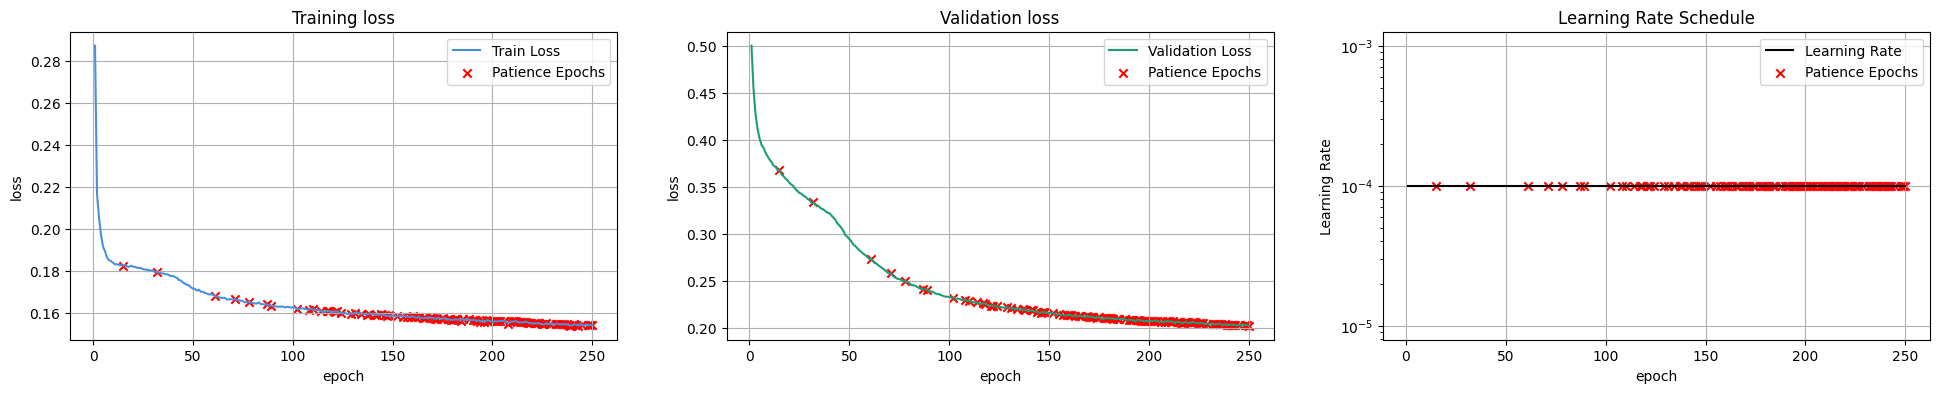

In [ ]:
gatv2_2 = GATv2LSTMModel(gl2, name = 'gatv2_geographical_neighbors1', verbose = 10)
gatv2_2.set_model_hparams()
gatv2_2.set_global_hparams(**global_hparams)
gatv2_2.train()
gatv2_2.forecast('test')


==                gatv2_commuer1                ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 7), y=(400, 1), edge_index=(2, 3905), edge_weight=(3905,))
Epoch 001 train loss: 0.2833, val loss: 0.5178 ✓ (new best)
Epoch 002 train loss: 0.2280, val loss: 0.4695 ✓ (new best)
Epoch 003 train loss: 0.2141, val loss: 0.4480 ✓ (new best)
Epoch 004 train loss: 0.2040, val loss: 0.4311 ✓ (new best)
Epoch 005 train loss: 0.1977, val loss: 0.4237 ✓ (new best)
Epoch 006 train loss: 0.1951, val loss: 0.4164 ✓ (new best)
Epoch 007 train loss: 0.1939, val loss: 0.4125 ✓ (new best)
Epoch 008 train loss: 0.1930, val loss: 0.4073 ✓ (new best)
Epoch 009 train loss: 0.1924, val loss: 0.4059 ✓ (new best)
Epoch 010 train loss: 0.1921, val loss: 0.4004 ✓ (new best)
Epoch 011 train loss: 0.1915, val loss: 0.3968 ✓ (new best)
Epoch 012 train loss: 0.1907, val loss: 0.3924 ✓ (new best)
Epoch 013 train loss: 0.1900, val loss: 0.3903 ✓ (new best)
Epoch 014 train loss: 0.18

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:254: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Epoch 250 train loss: 0.1442, val loss: 0.1521 (patience: 8/20)
lr has been updated from 1.25e-05 to 6.25e-06
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 219.77it/s]

Test loss: 0.2285
forecasted ✓


GATv2LSTMModel(name='gatv2_commuer1')

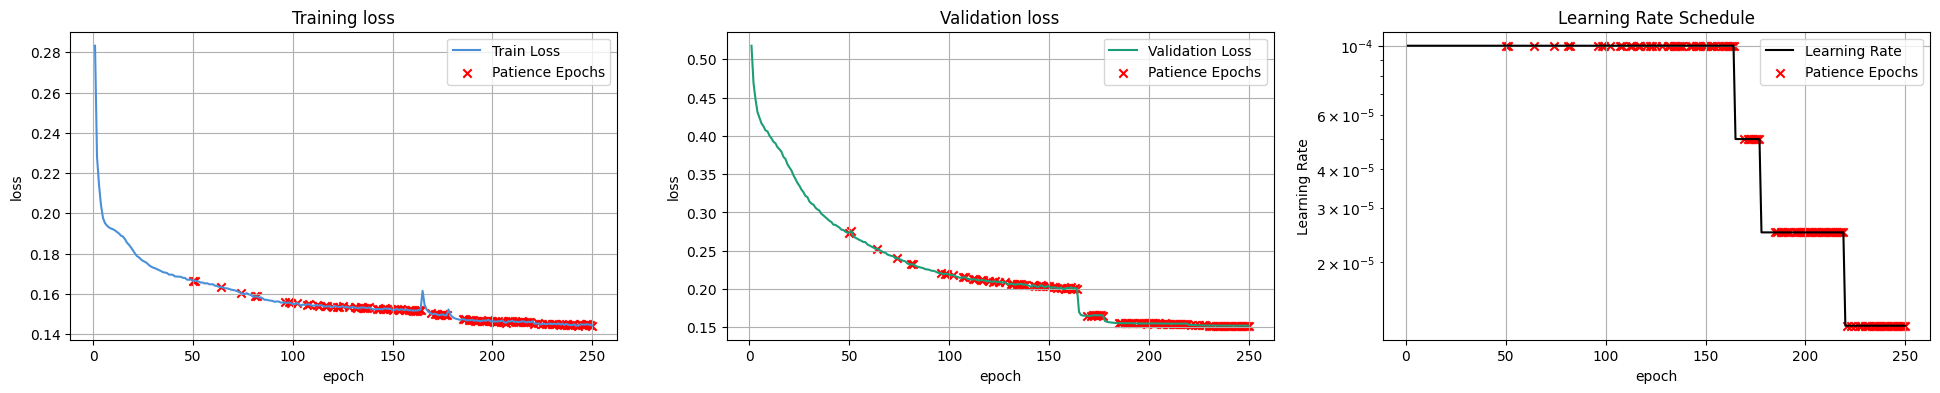

In [ ]:
gatv2_3 = GATv2LSTMModel(gl3, name = 'gatv2_commuer1', verbose = 10)
gatv2_3.set_model_hparams()
gatv2_3.set_global_hparams(**global_hparams)
gatv2_3.train()
gatv2_3.forecast('test')

In [ ]:
from src.evaluation import Evaluator

evaluation_experiment_gcn   = Evaluator([gatv2_1, gatv2_2, gatv2_3]).add_evaluation()
f_merged_raw_gcn            = evaluation_experiment_gcn.plotter.plot_metric_compilation(subfig_size = (8,4), metrics = ['r2','pearson_corr','node_smape','ccc'], plot_types = ['box','box','box','box']);




computing metrics:   0%|                                                                                | 0/8 [00:00<?, ?it/s]

computing metrics: 100%|████████████████████████████████████████████████████████████████████████| 8/8 [00:08<00:00,  1.01s/it]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels

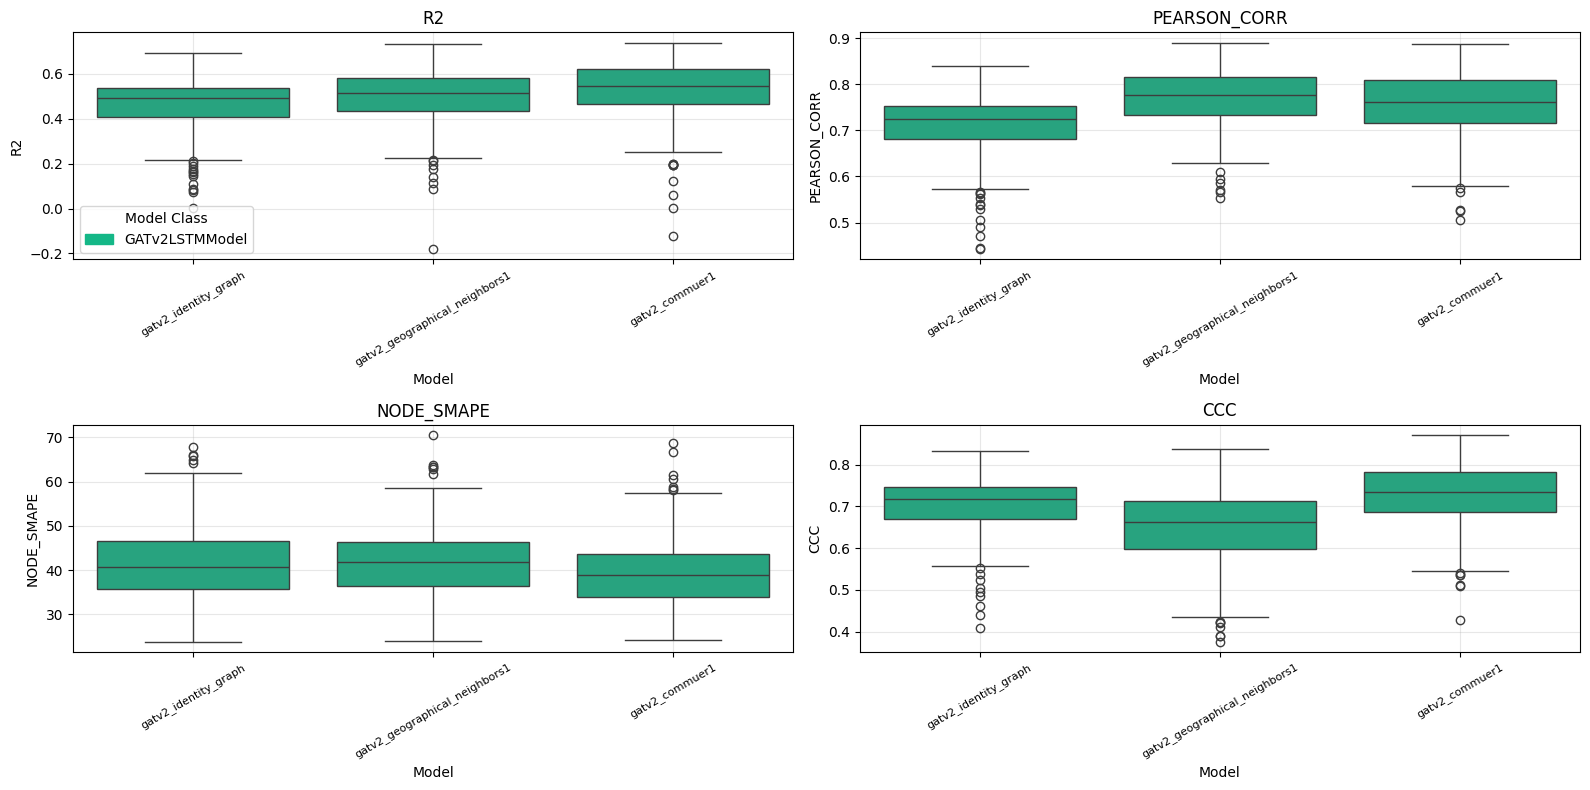

In [ ]:
f_merged_raw_gcn.show()

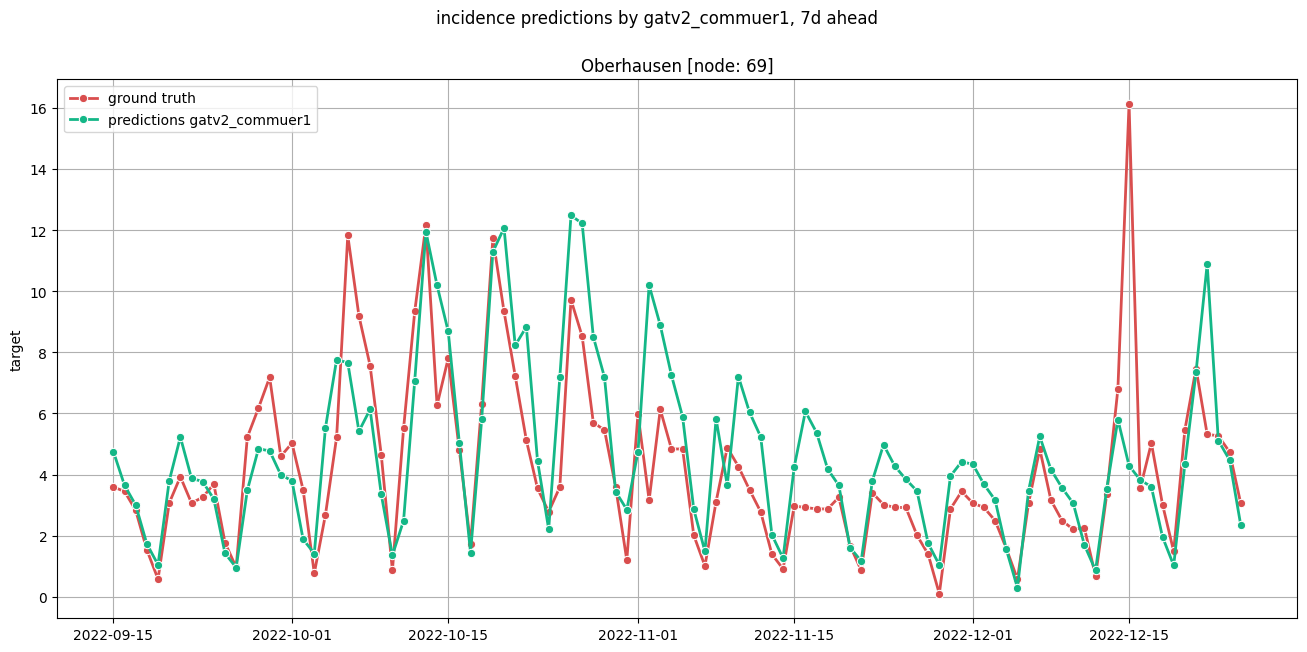

In [ ]:
gatv2_3.show_forecasts(69).show()

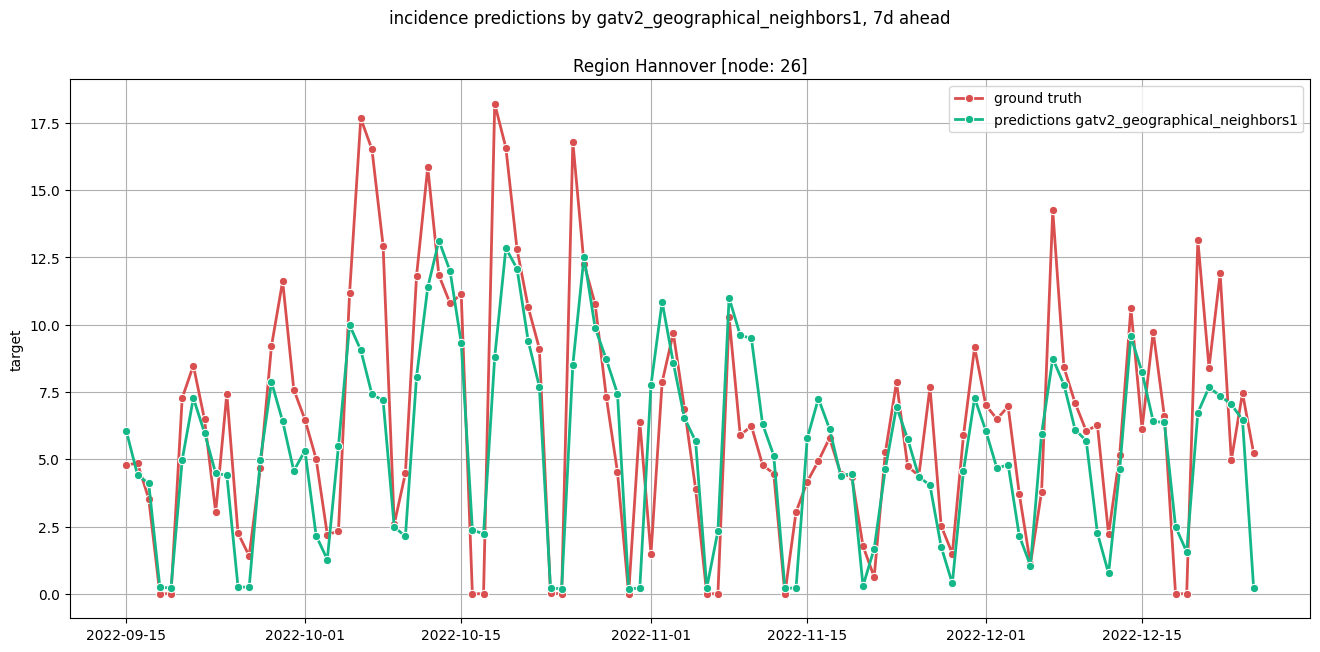

In [ ]:
gatv2_2.show_forecasts(26).show()

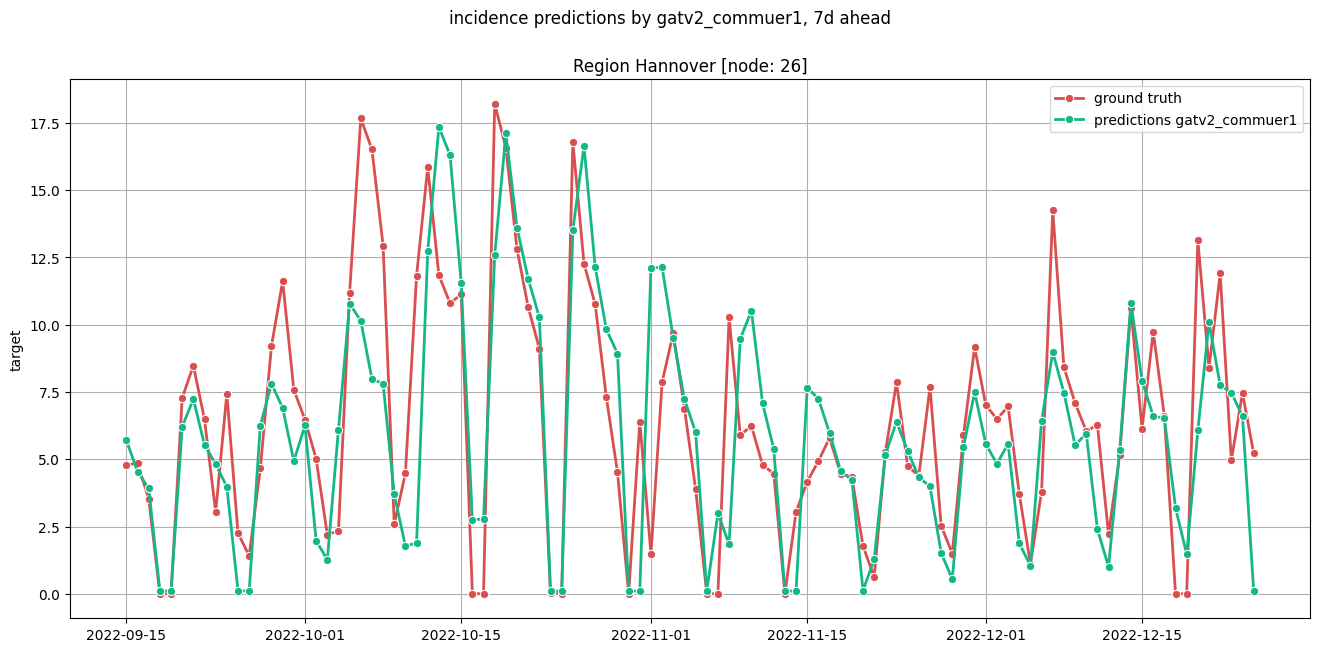

In [ ]:
gatv2_3.show_forecasts(26).show()

In [ ]:
from src.dataloading import ShallowDataLoaderManager, GraphDataLoaderManager, BaseLineDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, ClimaScaleModel

sl = BaseLineDataLoaderManager(data_orchestrator)
dl = DeepDataLoaderManager(data_orchestrator).construct_dataloaders()


ps = PersistenceModel(sl)
cm = ClimateologyModel(sl)
cms= ClimaScaleModel(sl)

ps.forecast('test')
raw_f1 = ps.show_forecasts([26], 'test')

cm.forecast('test')
raw_f2 = cm.show_forecasts([26], 'test')

cms.forecast('test')

ClimaScaleModel(name='climascale_model')

In [ ]:
from src.evaluation import Evaluator

evaluation_experiment_gcn   = Evaluator([ps, cm, cms, gatv2_1, gatv2_2, gatv2_3]).add_evaluation()
f_merged_raw_gcn            = evaluation_experiment_gcn.plotter.plot_metric_compilation(subfig_size = (8,4), metrics = ['r2','pearson_corr','node_smape','ccc'], plot_types = ['box','box','box','box']);




computing metrics: 100%|████████████████████████████████████████████████████████████████████████| 8/8 [00:14<00:00,  1.78s/it]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels

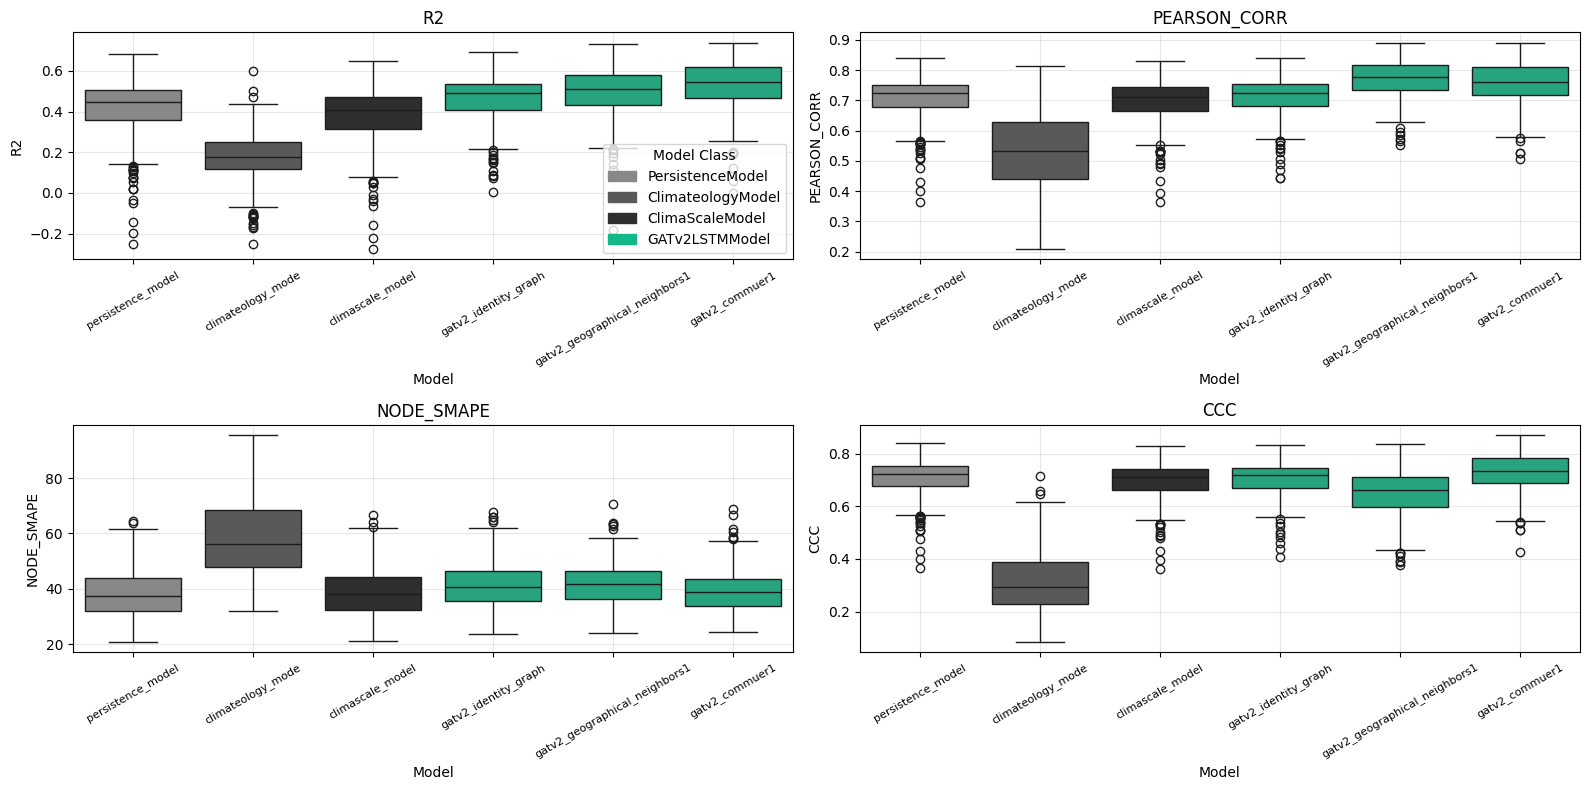

In [ ]:
f_merged_raw_gcn.show()

Moran's I for errors: 0.437
(Positive = errors clustered, 0 = random, Negative = dispersed)
